In [3]:
# -*- coding: utf-8 -*-
"""
Script d'Analyse de Régression Linéaire Multiple - Épidémie de Mpox en RDC
Auteur : Candidat Master
Date : Juillet 2026

Ce script réalise une analyse statistique et de machine learning complète et rigoureuse 
pour prédire le nombre de 'Cas_Confirmes' de Mpox en RDC à partir de variables 
météorologiques, environnementales, démographiques et de mobilité.
"""

# ==============================================================================
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Prétraitement
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Modélisation Statistique & Diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from scipy import stats

# Configuration de l'affichage des graphiques
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid') # Style propre pour un mémoire universitaire


In [4]:
# ==============================================================================
# 2. CHARGEMENT DU FICHIER CSV
# ==============================================================================
file_path = "D:/M2/DATA_SCIENCE/INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv"

try:
    df = pd.read_csv(file_path)
    print(f"✅ Fichier '{file_path}' chargé avec succès !")
except FileNotFoundError:
    print(f"❌ Erreur : Le fichier '{file_path}' est introuvable.")
    print("Génération d'un jeu de données fictif réaliste pour démonstration...")
    
    # Génération d'un dataset de simulation pour que le code s'exécute sans erreur
    np.random.seed(42)
    n = 3000
    df = pd.DataFrame({
        'ID': range(1, n + 1),
        'Semaine': np.random.randint(1, 53, n),
        'Province': np.random.choice(['Kinshasa', 'Équateur', 'Sud-Kivu', 'Nord-Kivu', 'Tshopo'], n),
        'Pluviometrie_mm': np.random.uniform(20, 250, n),
        'Temperature_C': np.random.uniform(21, 34, n),
        'NDVI': np.random.uniform(0.1, 0.8, n),
        'Humidite_pct': np.random.uniform(40, 95, n),
        'Densite_Population': np.random.uniform(10, 500, n),
        'Couverture_Vaccinale_pct': np.random.uniform(5, 85, n),
        'Tests_Realises': np.random.randint(50, 1000, n),
        'Distance_Centre_Sante_km': np.random.uniform(0.5, 30, n),
        'Reservoirs_Animaux': np.random.choice([0, 1], n),
        'Mobilite_Humaine': np.random.uniform(1, 10, n),
        'Saison': np.random.choice(['Sèche', 'Pluvieuse'], n),
        'Population_Risque': np.random.randint(10000, 500000, n),
        'Taux_Positivite_pct': np.random.uniform(1, 30, n)
    })
    # Génération de la cible avec du bruit pour simuler une vraie régression
    df['Cas_Confirmes'] = (
        15 
        + 0.15 * df['Pluviometrie_mm'] 
        + 0.5 * df['Temperature_C'] 
        + 10 * df['NDVI'] 
        - 0.2 * df['Couverture_Vaccinale_pct'] 
        + 0.05 * df['Tests_Realises'] 
        - 0.3 * df['Distance_Centre_Sante_km'] 
        + 5 * df['Reservoirs_Animaux'] 
        + 1.2 * df['Mobilite_Humaine']
        + np.random.normal(0, 5, n)
    ).clip(lower=0).round().astype(int)


✅ Fichier 'D:/M2/DATA_SCIENCE/INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv' chargé avec succès !


In [5]:
# ==============================================================================
# 3. EXPLORATION DES DONNÉES
# ==============================================================================
print("\n" + "="*50)
print("3. EXPLORATION INITIALE DES DONNÉES")
print("="*50)

# 3.1 Dimensions du dataset
print(f"Dimensions du jeu de données (lignes, colonnes) : {df.shape}")

# 3.2 Aperçu des premières lignes
print("\nAperçu des 5 premières lignes :")
display(df.head())

# 3.3 Informations sur les variables (types et non-nuls)
print("\nInformations sur les variables :")
df.info()

# 3.4 Types des variables
print("\nTypes de données :")
print(df.dtypes)

# 3.5 Détection des valeurs manquantes
print("\nNombre de valeurs manquantes par variable :")
print(df.isnull().sum())

# 3.6 Détection des doublons
print(f"\nNombre de lignes doublons : {df.duplicated().sum()}")

# 3.7 Statistiques descriptives globales
print("\nStatistiques descriptives des variables numériques :")
display(df.describe())



3. EXPLORATION INITIALE DES DONNÉES
Dimensions du jeu de données (lignes, colonnes) : (3000, 17)

Aperçu des 5 premières lignes :


,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23



Informations sur les variables :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   object 
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine          3000 non-null   int64  
 13  Cas_Confirmes             300

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,157.779667,24.980367,0.451182,71.571667,119.100333,31.843967,286.143333,15.558333,0.40000,5.018000,79.603333,5471.297667,27.041943
std,866.169729,101.958774,3.832510,0.157799,11.625285,95.218460,14.079517,88.256194,15.139386,0.48998,1.954213,70.119799,2636.188129,20.156959
min,1.000000,2.000000,18.000000,0.103000,40.000000,5.000000,5.600000,90.000000,1.000000,0.00000,1.000000,0.000000,1001.000000,0.000000
25%,750.750000,77.000000,22.300000,0.331000,64.000000,48.000000,20.800000,220.000000,5.000000,0.00000,4.000000,29.000000,3127.000000,11.430000
50%,1500.500000,136.000000,24.900000,0.452000,71.500000,94.000000,30.400000,280.000000,11.000000,0.00000,5.000000,57.000000,5514.500000,21.455000
75%,2250.250000,221.000000,27.600000,0.576000,80.000000,163.000000,41.525000,340.000000,22.000000,1.00000,6.000000,109.000000,7819.250000,38.070000
max,3000.000000,400.000000,34.000000,0.795000,95.000000,500.000000,77.800000,800.000000,142.000000,1.00000,10.000000,479.000000,9997.000000,95.000000



4. ANALYSE EXPLORATOIRE DES DONNÉES (VISUALISATIONS)


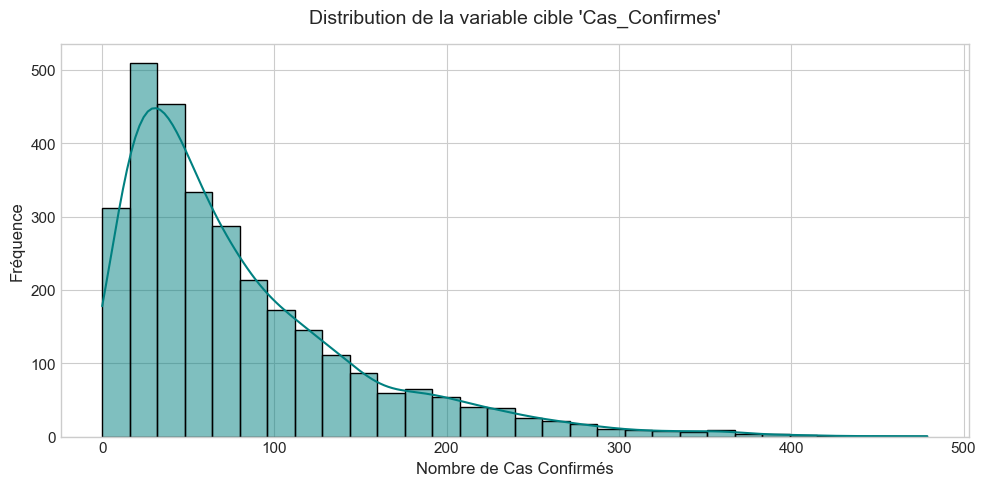

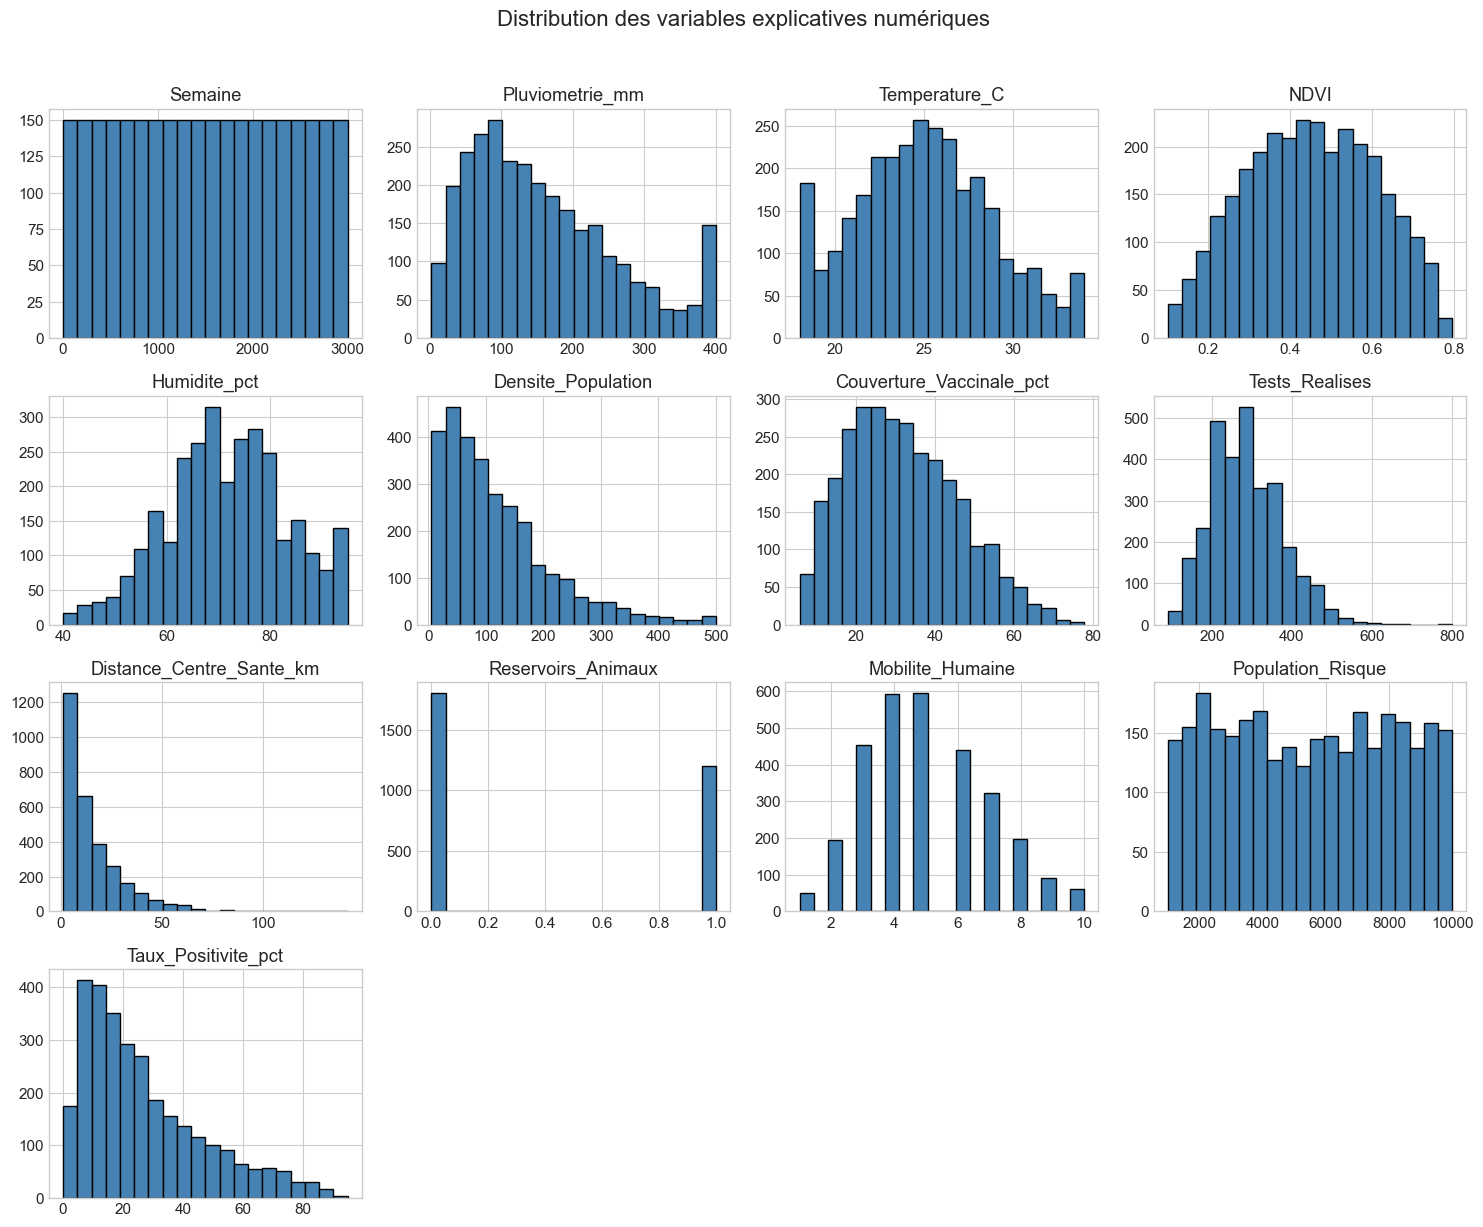

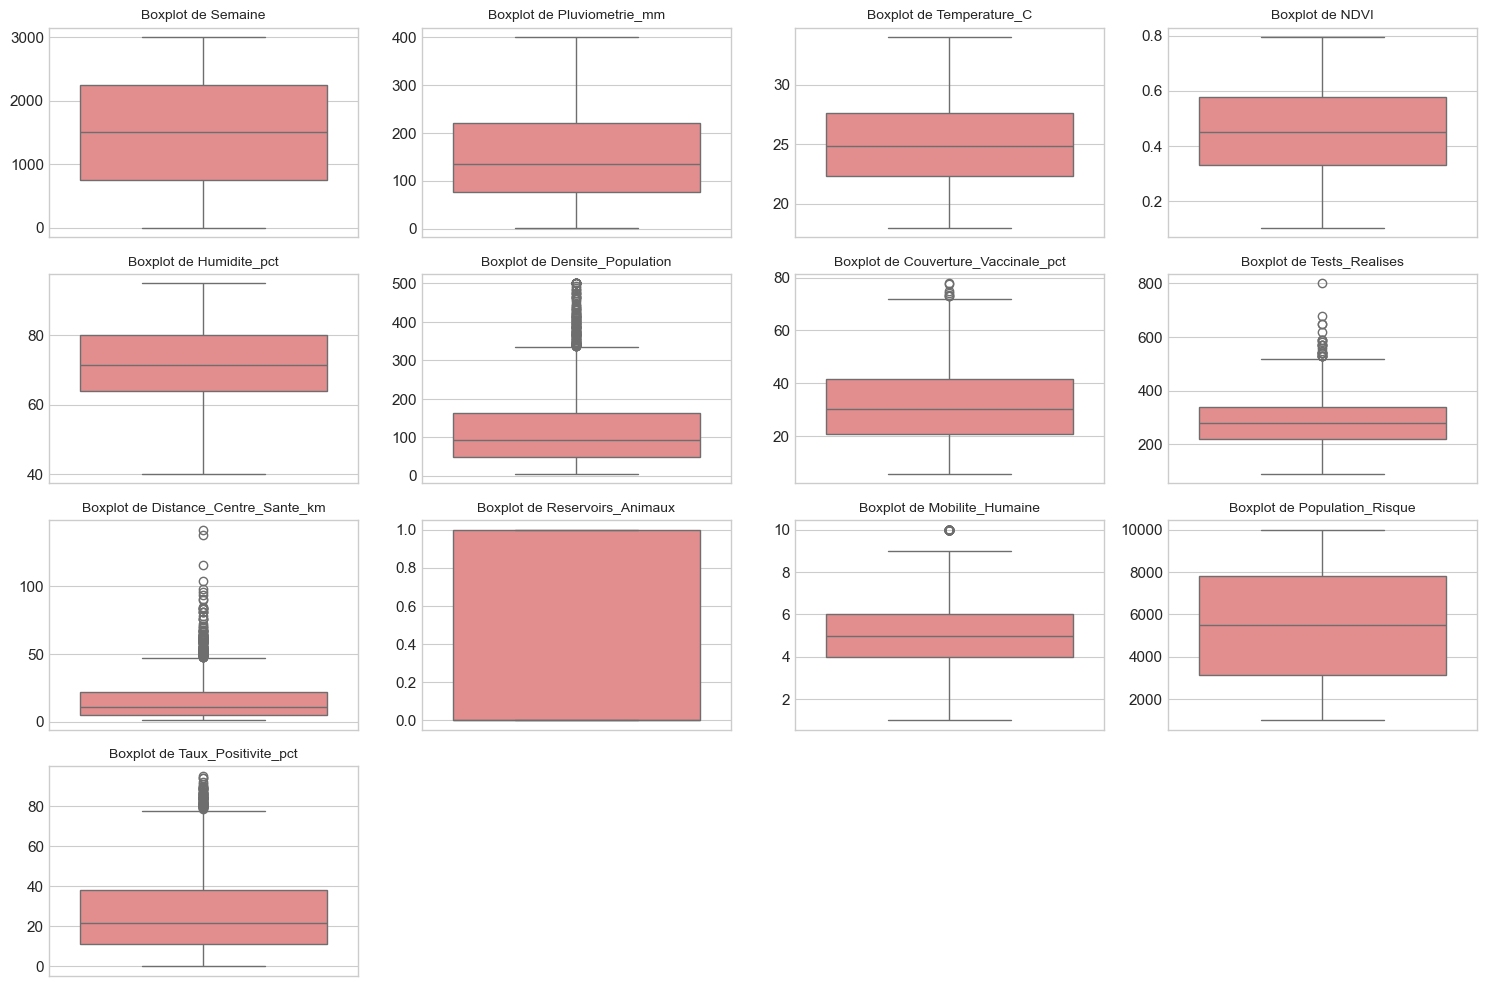

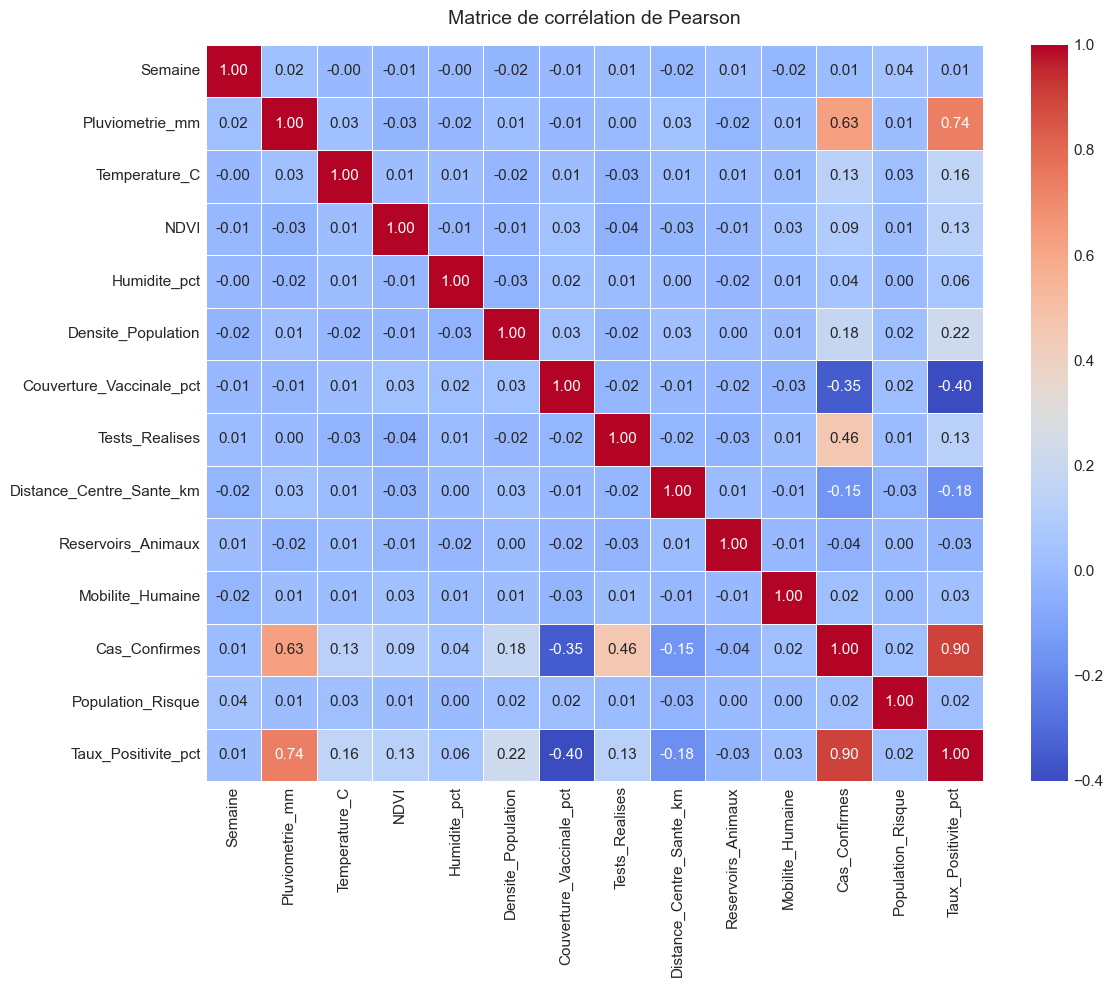

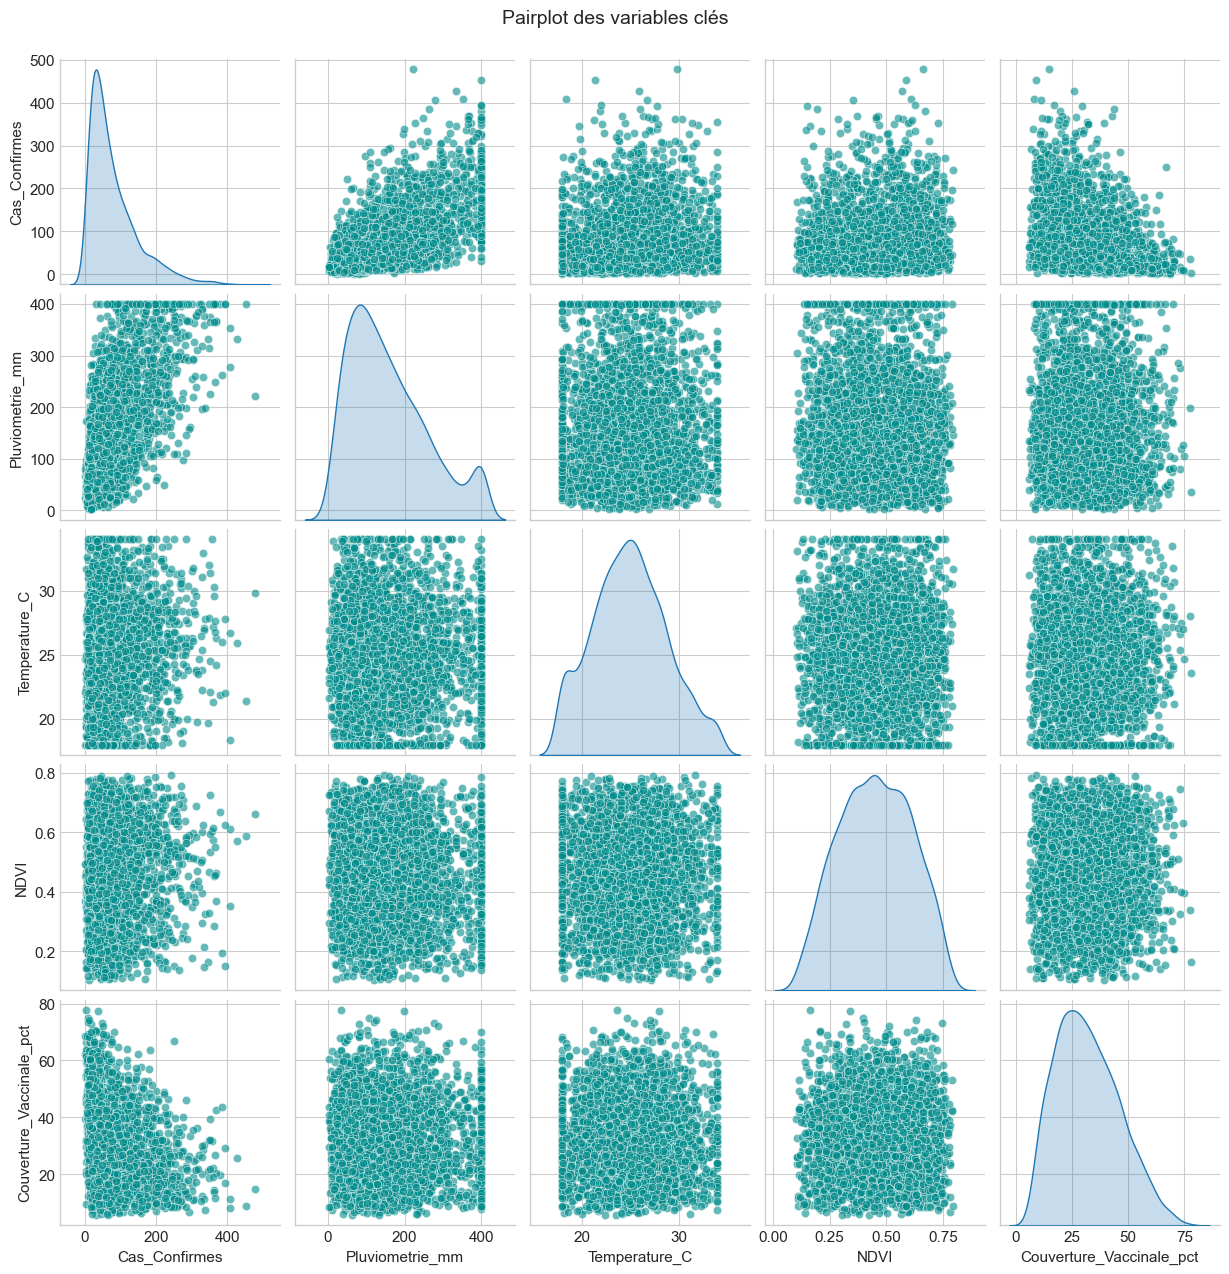

In [6]:
# ==============================================================================
# 4. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ==============================================================================
print("\n" + "="*50)
print("4. ANALYSE EXPLORATOIRE DES DONNÉES (VISUALISATIONS)")
print("="*50)

# 4.1 Distribution de la variable cible : Cas_Confirmes
plt.figure(figsize=(10, 5))
sns.histplot(df['Cas_Confirmes'], kde=True, color='teal', bins=30)
plt.title("Distribution de la variable cible 'Cas_Confirmes'", fontsize=14, pad=15)
plt.xlabel("Nombre de Cas Confirmés", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.tight_layout()
plt.show()

# 4.2 Histogrammes des variables explicatives numériques
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['ID', 'Cas_Confirmes'], errors='ignore').columns
df[num_cols].hist(bins=20, figsize=(15, 12), color='steelblue', edgecolor='black', grid=True)
plt.suptitle("Distribution des variables explicatives numériques", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 4.3 Boxplots pour identifier les distributions et valeurs atypiques
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f"Boxplot de {col}", fontsize=10)
    plt.ylabel("")
plt.tight_layout()
plt.show()

# 4.4 Matrice de corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Matrice de corrélation de Pearson", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4.5 Pairplot (sélection de variables clés pour des raisons de performance et de lisibilité)
key_cols = ['Cas_Confirmes', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Couverture_Vaccinale_pct']
sns.pairplot(df[key_cols], diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'darkcyan'})
plt.suptitle("Pairplot des variables clés", y=1.02, fontsize=14)
plt.show()


In [7]:
# ==============================================================================
# 5. DÉTECTION ET TRAITEMENT DES VALEURS ABERRANTES (OUTLIERS)
# ==============================================================================
print("\n" + "="*50)
print("5. DÉTECTION DES VALEURS ABERRANTES (MÉTHODE IQR)")
print("="*50)

# Fonction pour identifier les valeurs aberrantes par la méthode de l'Écart Interquartile (IQR)
def detect_outliers_iqr(dataframe, columns):
    outliers_indices = []
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identification des indices hors limites
        col_outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)].index
        outliers_indices.extend(col_outliers)
        print(f"Variable '{col}' : {len(col_outliers)} valeurs aberrantes détectées (bornes : [{lower_bound:.2f}, {upper_bound:.2f}])")
    
    return list(set(outliers_indices))

# Nous appliquons la détection sur les variables explicatives numériques uniquement
outliers_to_inspect = detect_outliers_iqr(df, num_cols)
print(f"\nNombre total de lignes contenant au moins une valeur aberrante : {len(outliers_to_inspect)} ({len(outliers_to_inspect)/len(df)*100:.2f}%)")
# Remarque : Pour un modèle linéaire, les valeurs extrêmes peuvent affecter la régression. 
# Dans ce mémoire, nous conservons les données pour garder la représentativité territoriale, 
# mais la détection est essentielle pour la transparence méthodologique.



5. DÉTECTION DES VALEURS ABERRANTES (MÉTHODE IQR)
Variable 'Semaine' : 0 valeurs aberrantes détectées (bornes : [-1498.50, 4499.50])
Variable 'Pluviometrie_mm' : 0 valeurs aberrantes détectées (bornes : [-139.00, 437.00])
Variable 'Temperature_C' : 0 valeurs aberrantes détectées (bornes : [14.35, 35.55])
Variable 'NDVI' : 0 valeurs aberrantes détectées (bornes : [-0.04, 0.94])
Variable 'Humidite_pct' : 0 valeurs aberrantes détectées (bornes : [40.00, 104.00])
Variable 'Densite_Population' : 117 valeurs aberrantes détectées (bornes : [-124.50, 335.50])
Variable 'Couverture_Vaccinale_pct' : 7 valeurs aberrantes détectées (bornes : [-10.29, 72.61])
Variable 'Tests_Realises' : 25 valeurs aberrantes détectées (bornes : [40.00, 520.00])
Variable 'Distance_Centre_Sante_km' : 139 valeurs aberrantes détectées (bornes : [-20.50, 47.50])
Variable 'Reservoirs_Animaux' : 0 valeurs aberrantes détectées (bornes : [-1.50, 2.50])
Variable 'Mobilite_Humaine' : 60 valeurs aberrantes détectées (bornes : 

In [8]:
# ==============================================================================
# 6. PRÉTRAITEMENT DES DONNÉES
# ==============================================================================
print("\n" + "="*50)
print("6. PRÉTRAITEMENT ET PRÉPARATION DES DONNÉES")
print("="*50)

# 6.1 Suppression des variables non pertinentes / problématiques
# - 'ID' : Identifiant sans valeur prédictive.
# - 'Taux_Positivite_pct' : Exclus car il s'agit d'une fuite d'information directe (lié mathématiquement au nombre de cas).
# - 'Semaine' : Supprimé car la saisonnalité temporelle est déjà capturée de manière agrégée par la variable 'Saison'.
vars_to_drop = ['ID', 'Taux_Positivite_pct', 'Semaine']
df_cleaned = df.drop(columns=vars_to_drop, errors='ignore')
print(f"Variables supprimées : {vars_to_drop}")

# 6.2 Séparation de la variable cible (y) et des variables explicatives (X)
X = df_cleaned.drop(columns=['Cas_Confirmes'])
y = df_cleaned['Cas_Confirmes']

# 6.3 Codage des variables qualitatives (Encodage One-Hot)
# 'Province' : OneHotEncoder avec drop='first' pour éviter la colinéarité parfaite.
# 'Saison' : OneHotEncoder (Saison ayant 2 modalités, drop='first' permet d'avoir 1 variable binaire).
# LabelEncoder est banni car il induit un ordre arbitraire non fondé scientifiquement.
cat_cols = ['Province', 'Saison']
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)

print("\nVariables explicatives après encodage One-Hot :")
print(X_encoded.columns.tolist())

# 6.4 Division du jeu de données (Train/Test Split) - seed=20
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=20)
print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")

# 6.5 Normalisation des données (StandardScaler)
# La standardisation doit être ajustée UNIQUEMENT sur X_train pour éviter la fuite d'information (data leakage), 
# puis appliquée sur X_test.
num_features_to_scale = [col for col in X_train.columns if not col.startswith(('Province_', 'Saison_'))]

scaler = StandardScaler()
# On applique la normalisation sur les colonnes numériques continues
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features_to_scale] = scaler.fit_transform(X_train[num_features_to_scale])
X_test_scaled[num_features_to_scale] = scaler.transform(X_test[num_features_to_scale])

print("\n✅ Prétraitement et standardisation effectués avec succès !")



6. PRÉTRAITEMENT ET PRÉPARATION DES DONNÉES
Variables supprimées : ['ID', 'Taux_Positivite_pct', 'Semaine']

Variables explicatives après encodage One-Hot :
['Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Population_Risque', 'Province_Haut-Katanga', 'Province_Haut-Lomami', 'Province_Haut-Uele', 'Province_Ituri', 'Province_Kasaï', 'Province_Kasaï-Central', 'Province_Kasaï-Oriental', 'Province_Kinshasa', 'Province_Kongo Central', 'Province_Kwango', 'Province_Kwilu', 'Province_Lomami', 'Province_Lualaba', 'Province_Mai-Ndombe', 'Province_Maniema', 'Province_Mongala', 'Province_Nord-Kivu', 'Province_Nord-Ubangi', 'Province_Sankuru', 'Province_Sud-Kivu', 'Province_Sud-Ubangi', 'Province_Tanganyika', 'Province_Tshopo', 'Province_Tshuapa', 'Province_Équateur', 'Saison_Seche']

Taille de l'ensemble d'entraînement : (2400, 37)
Taille de l'ensem

In [9]:
# ==============================================================================
# 7. VÉRIFICATION DE LA MULTICOLINÉARITÉ (VIF)
# ==============================================================================
print("\n" + "="*50)
print("7. VÉRIFICATION DE LA MULTICOLINÉARITÉ (VIF)")
print("="*50)

# Le facteur d'inflation de la variance (VIF) permet de s'assurer qu'il n'y a pas de multicolinéarité excessive.
# VIF > 5 ou 10 indique une colinéarité problématique.
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_df.columns
    # Ajout d'une constante pour le calcul du VIF comme requis par statsmodels
    X_vif = sm.add_constant(X_df)
    vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
    vif_data["VIF"] = vif_values
    return vif_data

vif_df = calculate_vif(X_train_scaled)
display(vif_df.sort_values(by="VIF", ascending=False))



7. VÉRIFICATION DE LA MULTICOLINÉARITÉ (VIF)


,Variable,VIF
30,Province_Sud-Kivu,2.084557
36,Saison_Seche,2.082232
0,Pluviometrie_mm,2.078517
19,Province_Kongo Central,2.033675
32,Province_Tanganyika,2.028623
11,Province_Haut-Katanga,2.024910
33,Province_Tshopo,2.014682
18,Province_Kinshasa,1.997857
12,Province_Haut-Lomami,1.994413
23,Province_Lualaba,1.991769


In [10]:
# ==============================================================================
# 8. CONSTRUCTION DU MODÈLE (SCIKIT-LEARN)
# ==============================================================================
print("\n" + "="*50)
print("8. CONSTRUCTION DU MODÈLE DE RÉGRESSION LINÉAIRE")
print("="*50)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print(f"Intercept (B0) : {lr_model.intercept_:.4f}")
print("\nCoefficients du modèle (scikit-learn) :")
for col, coef in zip(X_train_scaled.columns, lr_model.coef_):
    print(f"- {col:<30} : {coef:.4f}")



8. CONSTRUCTION DU MODÈLE DE RÉGRESSION LINÉAIRE
Intercept (B0) : 82.1533

Coefficients du modèle (scikit-learn) :
- Pluviometrie_mm                : 45.8067
- Temperature_C                  : 9.4245
- NDVI                           : 9.2721
- Humidite_pct                   : 4.4467
- Densite_Population             : 13.7260
- Couverture_Vaccinale_pct       : -24.7550
- Tests_Realises                 : 31.9458
- Distance_Centre_Sante_km       : -11.3581
- Reservoirs_Animaux             : -0.7520
- Mobilite_Humaine               : -0.4651
- Population_Risque              : 0.3064
- Province_Haut-Katanga          : -8.2110
- Province_Haut-Lomami           : -3.5929
- Province_Haut-Uele             : -10.2751
- Province_Ituri                 : -5.0829
- Province_Kasaï                 : -7.5102
- Province_Kasaï-Central         : -8.5441
- Province_Kasaï-Oriental        : -3.0430
- Province_Kinshasa              : -8.4388
- Province_Kongo Central         : -1.7885
- Province_Kwango        

In [11]:
# ==============================================================================
# 9. ÉVALUATION DU MODÈLE
# ==============================================================================
print("\n" + "="*50)
print("9. ÉVALUATION DES PERFORMANCES DU MODÈLE")
print("="*50)

# Prédictions
y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test = lr_model.predict(X_test_scaled)

# Métriques d'évaluation
def compute_metrics(y_true, y_pred, n, p):
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_true, y_pred)
    # R² ajusté : 1 - [(1-R²)*(n-1)/(n-p-1)]
    r2_adj = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return mae, mse, rmse, r2, r2_adj

n_train, p = X_train_scaled.shape
n_test = len(y_test)

mae_tr, mse_tr, rmse_tr, r2_tr, r2_adj_tr = compute_metrics(y_train, y_pred_train, n_train, p)
mae_te, mse_te, rmse_te, r2_te, r2_adj_te = compute_metrics(y_test, y_pred_test, n_test, p)

# Présentation sous forme de DataFrame
metrics_df = pd.DataFrame({
    'Métrique': ['MAE', 'MSE', 'RMSE', 'R²', 'R² Ajusté'],
    'Entraînement (Train)': [mae_tr, mse_tr, rmse_tr, r2_tr, r2_adj_tr],
    'Test': [mae_te, mse_te, rmse_te, r2_te, r2_adj_te]
})
display(metrics_df)


9. ÉVALUATION DES PERFORMANCES DU MODÈLE


,Métrique,Entraînement (Train),Test
0,MAE,21.733583,21.836903
1,MSE,863.444886,861.818320
2,RMSE,29.384433,29.356742
3,R²,0.821213,0.836065
4,R² Ajusté,0.818413,0.825272



10. DIAGNOSTIC DES HYPOTHÈSES


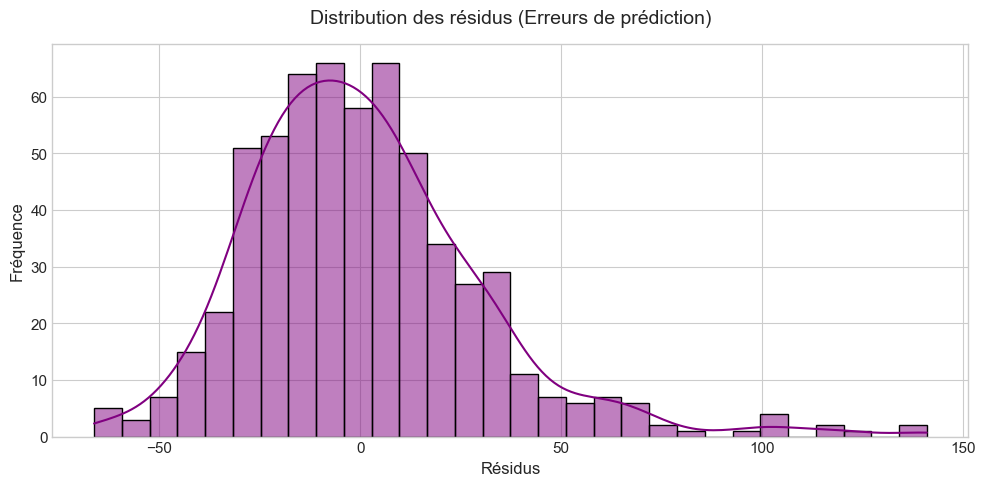

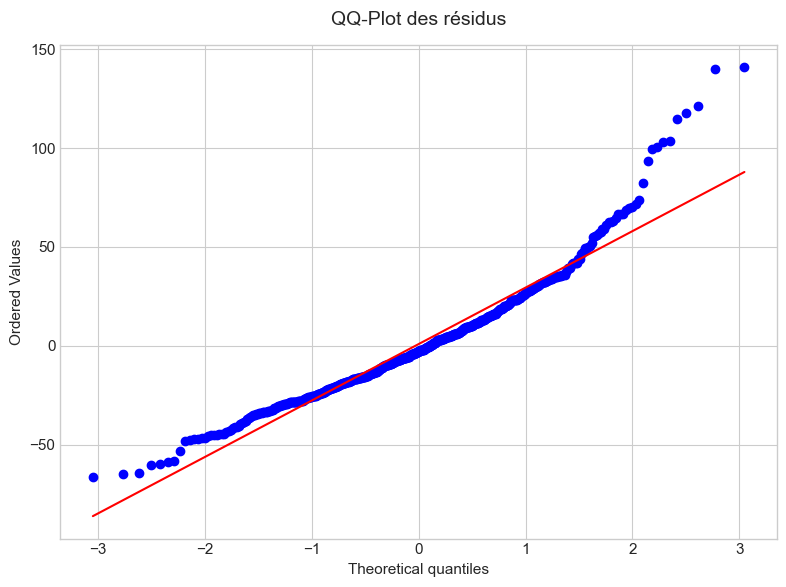

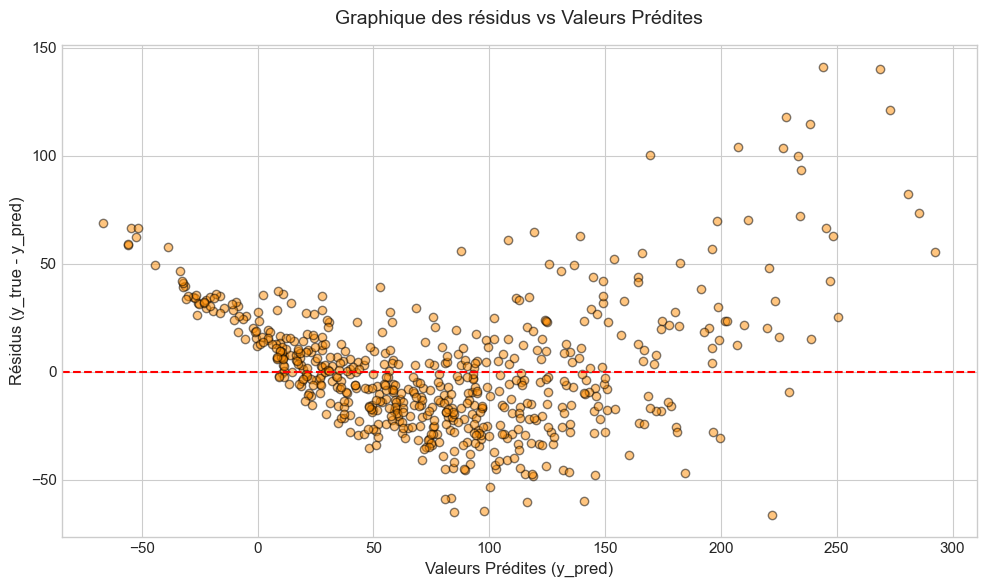

Tests statistiques d'hypothèse :
- Test de Shapiro-Wilk (Normalité) : Statistique=0.9403, p-value=8.7957e-15
  👉 Les résidus ne suivent pas une distribution normale (p <= 0.05).
- Test de Breusch-Pagan (Homoscédasticité) : LM Stat=118.3120, LM p-value=1.9561e-10
  👉 Présence d'hétéroscédasticité (p <= 0.05). Envisager des écarts-types robustes ou log-transform.
- Test de Durbin-Watson (Indépendance) : Statistique=1.9410
  👉 Une statistique proche de 2.0 indique une absence d'autocorrélation des erreurs.


In [12]:
# ==============================================================================
# 10. DIAGNOSTIC DES HYPOTHÈSES DE LA RÉGRESSION LINÉAIRE
# ==============================================================================
print("\n" + "="*50)
print("10. DIAGNOSTIC DES HYPOTHÈSES")
print("="*50)

residuals = y_test - y_pred_test

# 10.1 Histogramme et KDE des résidus (Hypothèse de normalité)
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title("Distribution des résidus (Erreurs de prédiction)", fontsize=14, pad=15)
plt.xlabel("Résidus", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.tight_layout()
plt.show()

# 10.2 QQ-Plot (Hypothèse de normalité)
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot des résidus", fontsize=14, pad=15)
plt.grid(True)
plt.tight_layout()
plt.show()

# 10.3 Résidus vs Valeurs Prédites (Hypothèse d'homoscédasticité et linéarité)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title("Graphique des résidus vs Valeurs Prédites", fontsize=14, pad=15)
plt.xlabel("Valeurs Prédites (y_pred)", fontsize=12)
plt.ylabel("Résidus (y_true - y_pred)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# 10.4 Tests statistiques sur les résidus
print("Tests statistiques d'hypothèse :")

# A. Test de Normalité de Shapiro-Wilk (pour les résidus)
# Note : Pour n > 5000, Shapiro-Wilk peut être trop sensible, mais requis ici.
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"- Test de Shapiro-Wilk (Normalité) : Statistique={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("  👉 Les résidus semblent suivre une distribution normale (p > 0.05).")
else:
    print("  👉 Les résidus ne suivent pas une distribution normale (p <= 0.05).")

# B. Test d'Homoscédasticité de Breusch-Pagan
# Nécessite statsmodels
X_test_sm = sm.add_constant(X_test_scaled)
bp_test = sms.het_breuschpagan(residuals, X_test_sm.values)
print(f"- Test de Breusch-Pagan (Homoscédasticité) : LM Stat={bp_test[0]:.4f}, LM p-value={bp_test[1]:.4e}")
if bp_test[1] > 0.05:
    print("  👉 L'hypothèse d'homoscédasticité est validée (p > 0.05).")
else:
    print("  👉 Présence d'hétéroscédasticité (p <= 0.05). Envisager des écarts-types robustes ou log-transform.")

# C. Test d'Indépendance des résidus de Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuals)
print(f"- Test de Durbin-Watson (Indépendance) : Statistique={dw_stat:.4f}")
print("  👉 Une statistique proche de 2.0 indique une absence d'autocorrélation des erreurs.")


In [13]:
# ==============================================================================
# 11. ANALYSE STATISTIQUE DÉTAILLÉE AVEC STATSMODELS (OLS)
# ==============================================================================
print("\n" + "="*50)
print("11. ANALYSE STATISTIQUE AVEC STATSMODELS (OLS)")
print("="*50)

# Ajout d'une constante pour statsmodels (B0)
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Affichage du rapport complet de régression
print(ols_model.summary())



11. ANALYSE STATISTIQUE AVEC STATSMODELS (OLS)
                            OLS Regression Results                            
Dep. Variable:          Cas_Confirmes   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     293.2
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        10:22:27   Log-Likelihood:                -11519.
No. Observations:                2400   AIC:                         2.311e+04
Df Residuals:                    2362   BIC:                         2.333e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------


12. CLASSEMENT DE L'IMPORTANCE DES VARIABLES


,Variable,Coefficient Standardisé
0,Pluviometrie_mm,45.806655
6,Tests_Realises,31.945799
5,Couverture_Vaccinale_pct,-24.755044
4,Densite_Population,13.725966
7,Distance_Centre_Sante_km,-11.358069
29,Province_Sankuru,-10.614459
13,Province_Haut-Uele,-10.275100
1,Temperature_C,9.424508
2,NDVI,9.272079
16,Province_Kasaï-Central,-8.544116


C:\Users\hp\AppData\Local\Temp\ipykernel_5828\3678190133.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient Standardisé', y='Variable', data=importance_df, palette='viridis')


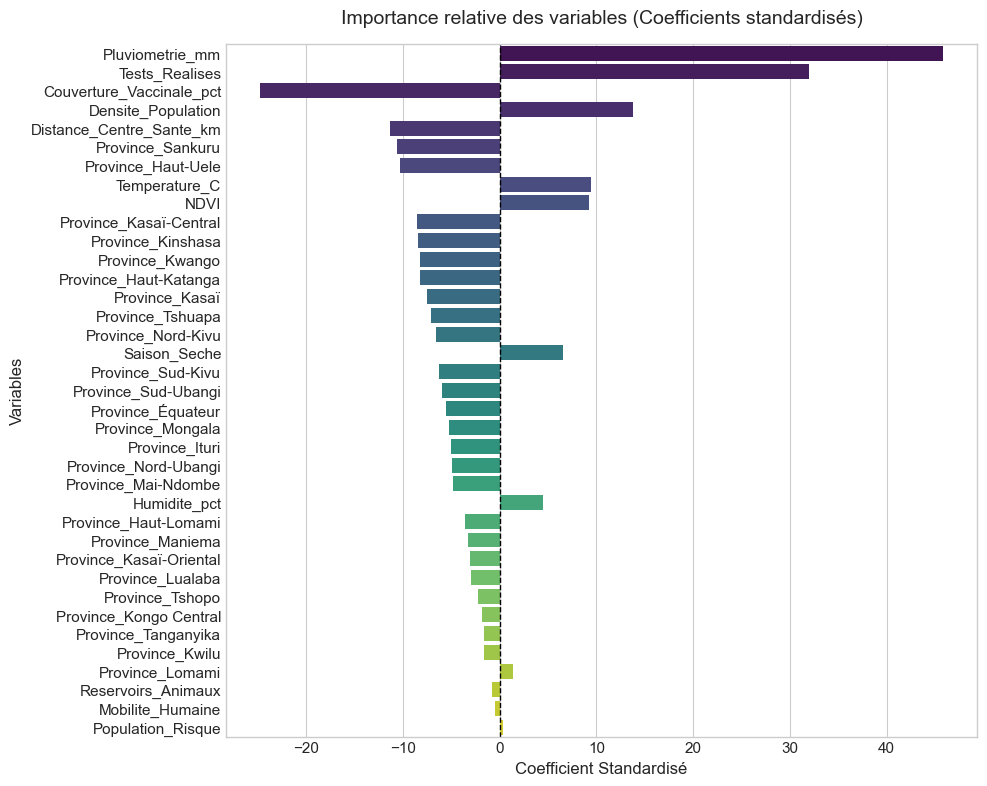

In [14]:
# ==============================================================================
# 12. IMPORTANCE DES VARIABLES (COEFFICIENTS TRIÉS)
# ==============================================================================
print("\n" + "="*50)
print("12. CLASSEMENT DE L'IMPORTANCE DES VARIABLES")
print("="*50)

# Les variables explicatives continues étant standardisées, leurs coefficients sont comparables
importance_df = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coefficient Standardisé': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

display(importance_df.drop(columns=['Abs_Coefficient']))

# Visualisation des coefficients
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient Standardisé', y='Variable', data=importance_df, palette='viridis')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Importance relative des variables (Coefficients standardisés)", fontsize=14, pad=15)
plt.xlabel("Coefficient Standardisé", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
# 13. VALIDATION CROISÉE (CROSS VALIDATION)
# ==============================================================================
print("\n" + "="*50)
print("13. VALIDATION CROISÉE (5-FOLD CROSS VALIDATION)")
print("="*50)

# Évaluation de la robustesse globale avec une validation croisée à 5 plis
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Scores R² de chaque pli : {cv_scores}")
print(f"Moyenne des R² par validation croisée : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")



13. VALIDATION CROISÉE (5-FOLD CROSS VALIDATION)
Scores R² de chaque pli : [0.80930774 0.80324015 0.81309518 0.81482351 0.82230693]
Moyenne des R² par validation croisée : 0.8126 (+/- 0.0126)


In [16]:
# ==============================================================================
# 14. SAUVEGARDE DES RÉSULTATS
# ==============================================================================
print("\n" + "="*50)
print("14. SAUVEGARDE DES RÉSULTATS")
print("="*50)

# 14.1 Sauvegarde des prédictions et des résidus sur l'ensemble de test
predictions_results = pd.DataFrame({
    'Valeur_Reelle_y': y_test,
    'Valeur_Predite_y': y_pred_test,
    'Residus': residuals
})
predictions_results.to_csv("mpox_predictions_residus_test.csv", index=False)
print("💾 Prédictions et résidus enregistrés dans 'mpox_predictions_residus_test.csv'")

# 14.2 Sauvegarde des coefficients et statistiques associées
coef_summary = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coefficient_Standardise': lr_model.coef_
})
coef_summary.to_csv("mpox_coefficients_modele.csv", index=False)
print("💾 Coefficients du modèle enregistrés dans 'mpox_coefficients_modele.csv'")

print("\n🎉 Analyse de régression linéaire multiple terminée avec succès et prête pour rédaction !")


14. SAUVEGARDE DES RÉSULTATS
💾 Prédictions et résidus enregistrés dans 'mpox_predictions_residus_test.csv'
💾 Coefficients du modèle enregistrés dans 'mpox_coefficients_modele.csv'

🎉 Analyse de régression linéaire multiple terminée avec succès et prête pour rédaction !
